###**Imports and Environment Setup**

In [ ]:
import os
import shutil
import random
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from IPython.display import display
from PIL import Image as PILImage
from google.colab import drive
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report


# Mount Google Drive
drive.mount('/content/drive')

print(f"TensorFlow Version: {tf.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow Version: 2.19.0


###**Project Configuration**

In [ ]:
# Directory paths
DATA_DIR = '/content/drive/MyDrive/images'
TRAIN_DIR = '/content/train'
VAL_DIR = '/content/validation'
MODEL_SAVE_PATH = '/content/drive/MyDrive/DSA447_Project'

# Hyperparameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 0.001
TRAIN_SPLIT = 0.85

print("Configuration parameters initialized.")

Configuration parameters initialized.


###**Utility Functions - Image Preprocessing**

In [ ]:
def convert_all_images_to_jpg(data_dir):
    """
    Standardizes dataset by converting non-JPG images (WebP, PNG, etc.) to JPEG format.
    Ensures compatibility with TensorFlow's ImageDataGenerator.
    """
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found at {data_dir}")
        return

    total_converted = 0
    folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

    print("Initiating image format conversion...")

    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
        files = os.listdir(folder_path)
        image_files = [f for f in files if f.lower().endswith(('.webp', '.png', '.bmp', '.gif'))]

        for img_file in image_files:
            try:
                original_path = os.path.join(folder_path, img_file)
                jpg_path = os.path.join(folder_path, img_file.rsplit('.', 1)[0] + '.jpg')

                img = PILImage.open(original_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')

                img.save(jpg_path, 'JPEG', quality=95)
                os.remove(original_path)
                total_converted += 1
            except Exception as e:
                print(f"Failed to convert {img_file}: {str(e)}")

    print(f"Conversion complete. Total images converted: {total_converted}")

# Execute conversion
convert_all_images_to_jpg(DATA_DIR)

Initiating image format conversion...
Conversion complete. Total images converted: 0


### **Dataset Analysis**

Found 8 classes. Total Dataset Size: 396
Training: ~336 images | Validation: ~60 images

  - orion: 49 images
  - ursa_major: 49 images
  - cassiopeia: 50 images
  - crux: 51 images
  - scorpius: 50 images
  - cygnus: 49 images
  - leo: 49 images
  - gemini: 49 images


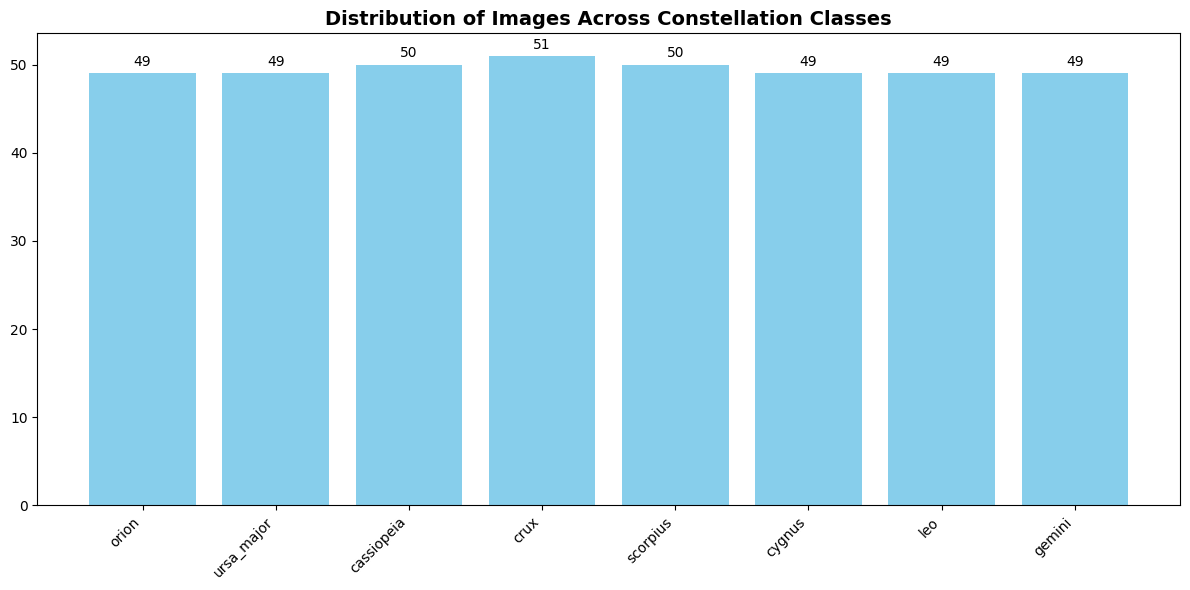

In [ ]:
if os.path.exists(DATA_DIR):
    # 1. Build the dictionary dynamically: {constellation: count}
    image_counts = {
        cls: len([f for f in os.listdir(os.path.join(DATA_DIR, cls)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for cls in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, cls))
    }

    total_images = sum(image_counts.values())

    # 2. Print concise text summary
    print(f"Found {len(image_counts)} classes. Total Dataset Size: {total_images}")
    print(f"Training: ~{int(total_images * TRAIN_SPLIT)} images | Validation: ~{total_images - int(total_images * TRAIN_SPLIT)} images\n")

    for cls, count in image_counts.items():
        print(f"  - {cls}: {count} images")

    # 3. Generate the plot directly from the dictionary
    plt.figure(figsize=(12, 6))
    bars = plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')

    plt.title('Distribution of Images Across Constellation Classes', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.bar_label(bars, padding=3)

    plt.tight_layout()
    plt.show()

else:
    print(f"Error: Could not find directory {DATA_DIR}")

###**Data Visualization**

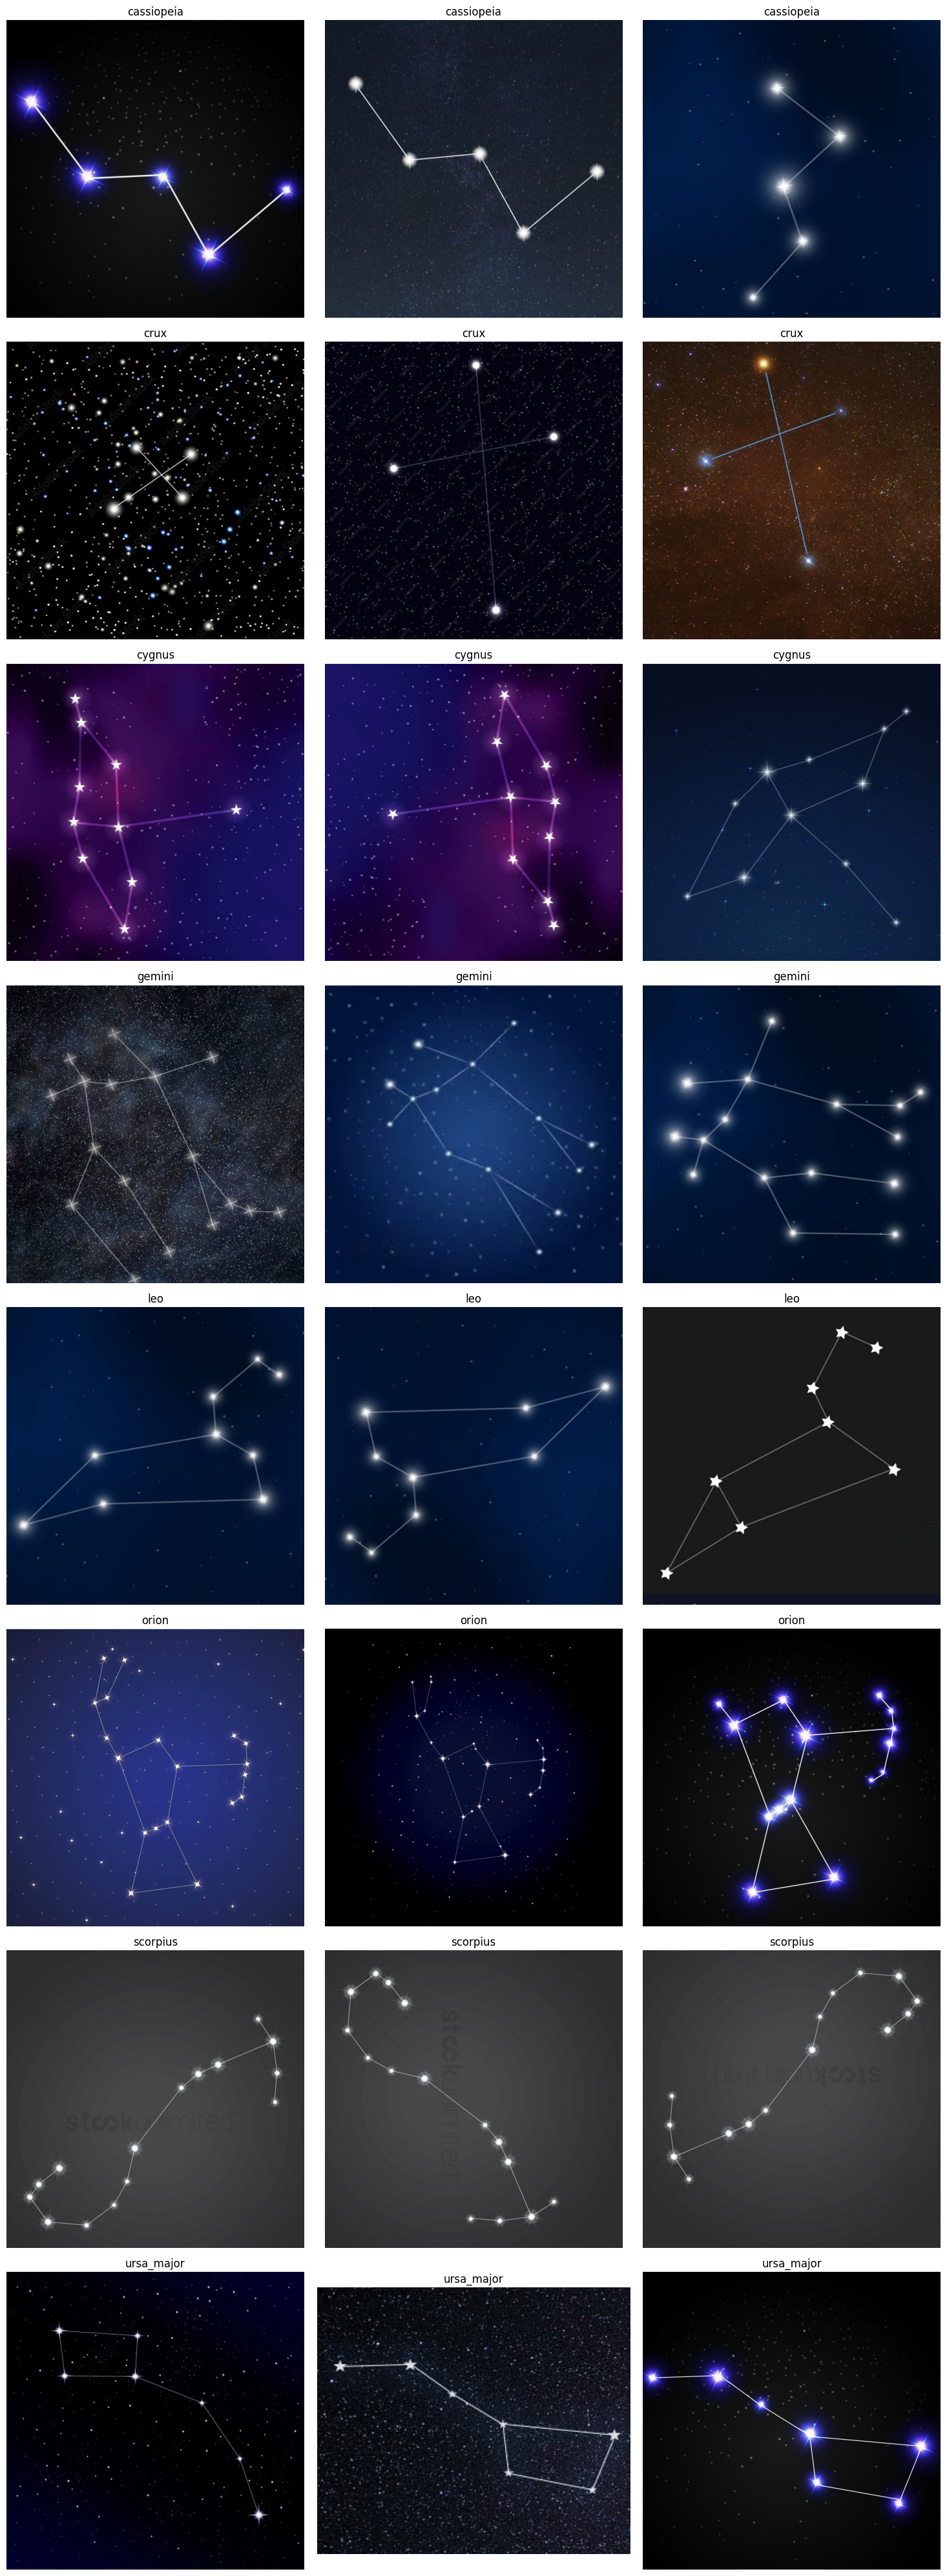

In [ ]:
def plot_sample_images(data_dir, num_samples=3):
    """Displays sample images from each constellation class."""
    classes = sorted([f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))])
    plt.figure(figsize=(15, 5 * len(classes)))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        img_names = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg'))][:num_samples]

        for i, img_name in enumerate(img_names):
            plt.subplot(len(classes), num_samples, idx * num_samples + i + 1)
            img = load_img(os.path.join(cls_path, img_name))
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_sample_images(DATA_DIR)

### **Split Data into Training and Validation Sets**

In [ ]:
def split_data(source_dir, train_dir, val_dir, split_ratio=0.8):
    """
    Splits an image directory into fresh training and validation sets.

    Args:
        source_dir: Directory containing original constellation folders.
        train_dir: Destination for training images.
        val_dir: Destination for validation images.
        split_ratio: Fraction of images to use for training (default: 0.8).
    """
    if os.path.exists(train_dir):
        shutil.rmtree(train_dir)
    if os.path.exists(val_dir):
        shutil.rmtree(val_dir)

    os.makedirs(train_dir)
    os.makedirs(val_dir)

    constellation_folders = [f for f in os.listdir(source_dir)
                             if os.path.isdir(os.path.join(source_dir, f))]

    print("Splitting data into training and validation sets...\n")

    for folder in constellation_folders:
        os.makedirs(os.path.join(train_dir, folder))
        os.makedirs(os.path.join(val_dir, folder))

        source_folder = os.path.join(source_dir, folder)
        images = [f for f in os.listdir(source_folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        np.random.shuffle(images)
        split_point = int(len(images) * split_ratio)

        train_images = images[:split_point]
        val_images = images[split_point:]

        for img in train_images:
            shutil.copy2(os.path.join(source_folder, img), os.path.join(train_dir, folder, img))

        for img in val_images:
            shutil.copy2(os.path.join(source_folder, img), os.path.join(val_dir, folder, img))

        print(f"  {folder}:")
        print(f"    → Training: {len(train_images)} images")
        print(f"    → Validation: {len(val_images)} images")

    print("\n✓ Data split complete!")

split_data(DATA_DIR, TRAIN_DIR, VAL_DIR, TRAIN_SPLIT)

Splitting data into training and validation sets...

  orion:
    → Training: 41 images
    → Validation: 8 images
  ursa_major:
    → Training: 41 images
    → Validation: 8 images
  cassiopeia:
    → Training: 42 images
    → Validation: 8 images
  crux:
    → Training: 43 images
    → Validation: 8 images
  scorpius:
    → Training: 42 images
    → Validation: 8 images
  cygnus:
    → Training: 41 images
    → Validation: 8 images
  leo:
    → Training: 41 images
    → Validation: 8 images
  gemini:
    → Training: 41 images
    → Validation: 8 images

✓ Data split complete!


### **Data Augmentation**

In [ ]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest'
)

# Validation generator (rescaling only)
val_datagen = ImageDataGenerator(rescale=1./255)

print("Augmentation applied to training data.")

Augmentation applied to training data.


###**Load and Prepare Data**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("\nData loaded successfully!")
print(f"Classes ({num_classes}): {class_names}")
print(f"Samples - Training: {train_generator.samples} | Validation: {validation_generator.samples}")

Found 332 images belonging to 8 classes.
Found 64 images belonging to 8 classes.

Data loaded successfully!
Classes (8): ['cassiopeia', 'crux', 'cygnus', 'gemini', 'leo', 'orion', 'scorpius', 'ursa_major']
Samples - Training: 332 | Validation: 64


### **Image Augmentation Samples**

Visualizing augmentations for: leo / leo28.jpg


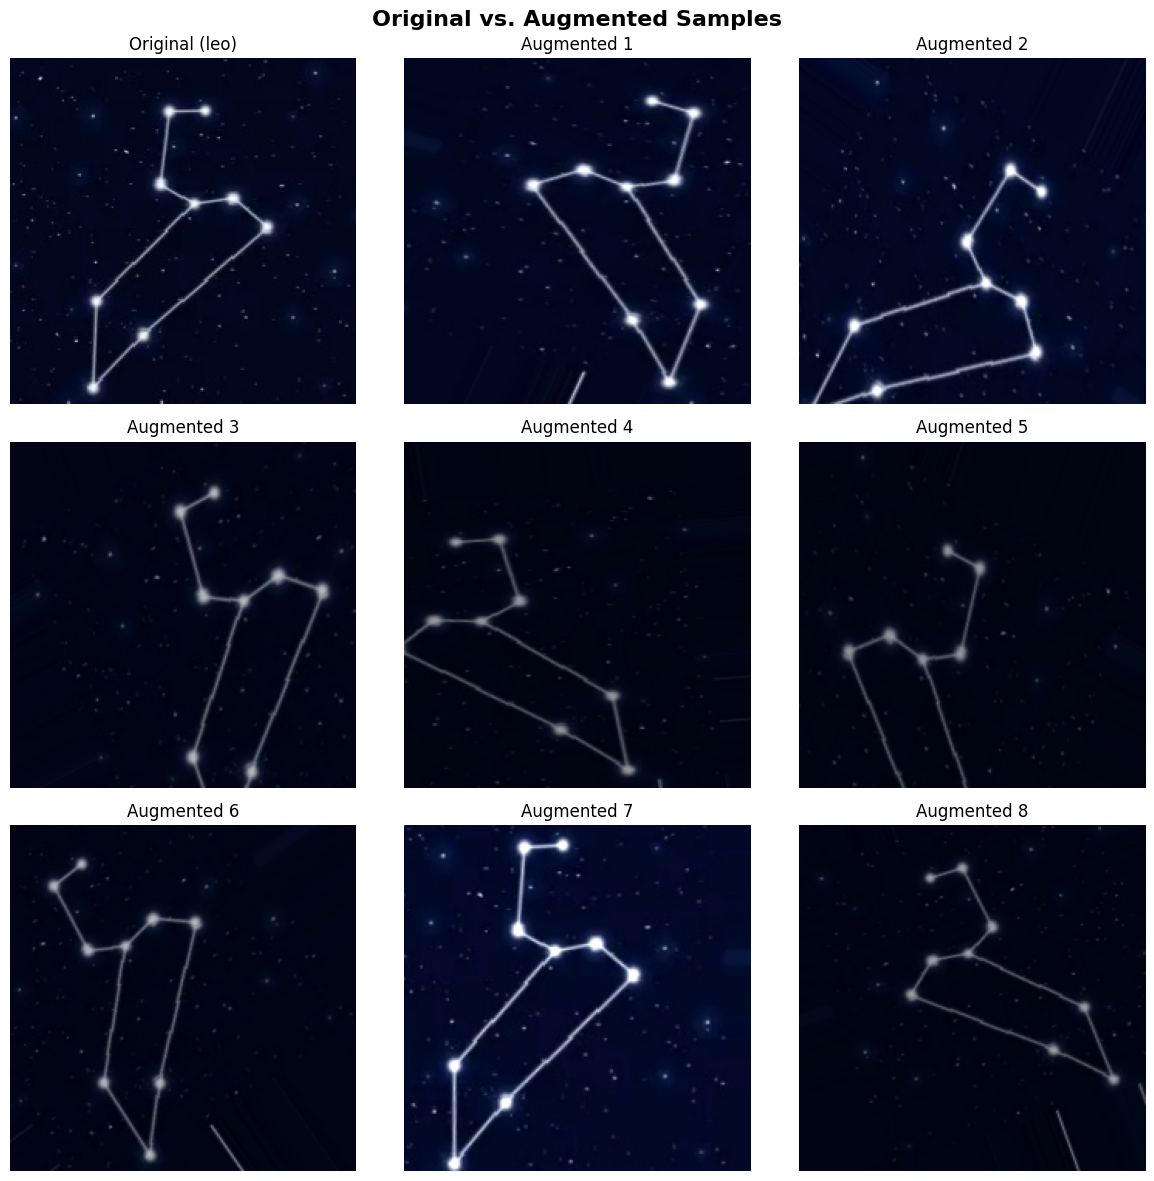

In [ ]:
# 1. Grab a random image path
random_cls = random.choice(os.listdir(TRAIN_DIR))
random_img = random.choice(os.listdir(os.path.join(TRAIN_DIR, random_cls)))
img_path = os.path.join(TRAIN_DIR, random_cls, random_img)

print(f"Visualizing augmentations for: {random_cls} / {random_img}")

# 2. Load and format the image for the generator
img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = np.expand_dims(image.img_to_array(img), axis=0)

# 3. Set up the plot
plt.figure(figsize=(12, 12))

# Display original (manually rescaled for display)
plt.subplot(3, 3, 1)
plt.imshow(img_array[0] / 255.0)
plt.title(f"Original ({random_cls})")
plt.axis('off')

# 4. Generate and display 8 augmented samples
aug_iterator = train_datagen.flow(img_array, batch_size=1)

for i in range(2, 10):
    plt.subplot(3, 3, i)
    plt.imshow(next(aug_iterator)[0])
    plt.title(f"Augmented {i-1}")
    plt.axis('off')

plt.suptitle('Original vs. Augmented Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

###**Build the CNN Model**

In [ ]:
def create_model(num_classes):
    """
    Creates a transfer learning CNN model using MobileNetV2.

    Args:
        num_classes: Number of constellation classes to predict.

    Returns:
        Compiled Keras model ready for training.
    """
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create the model and display its architecture
model = create_model(num_classes)

print("✓ Model created successfully!\n")
model.summary()

✓ Model created successfully!



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Train the Model**

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Calculate class weights to handle any dataset imbalance
weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(weights))

# 2. Configure training callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks and class weights configured!")

Callbacks and class weights configured!


In [ ]:
print(f"Starting training for up to {EPOCHS} epochs...\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✓ Training complete!")

Starting training for up to 50 epochs...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 639ms/step - accuracy: 0.1444 - loss: 2.4342 - val_accuracy: 0.6562 - val_loss: 1.4400 - learning_rate: 0.0010
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 527ms/step - accuracy: 0.4469 - loss: 1.5924 - val_accuracy: 0.7500 - val_loss: 1.0014 - learning_rate: 0.0010
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 602ms/step - accuracy: 0.5967 - loss: 1.2438 - val_accuracy: 0.6875 - val_loss: 0.8901 - learning_rate: 0.0010
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 529ms/step - accuracy: 0.5915 - loss: 1.1517 - val_accuracy: 0.7344 - val_loss: 0.8342 - learning_rate: 0.0010
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 600ms/step - accuracy: 0.5765 - loss: 1.1721 - val_accuracy: 0.7656 - val_loss: 0.7295 - learning_rate: 0.0010
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 525ms/step - accuracy: 0.6972 - loss: 0.8951 - val_accuracy: 0.8125 - val_loss: 0.5718 - learning_rate: 0.0010
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 605ms/step - accuracy: 0.6857 - loss: 0.

### **Visualize Training Results**

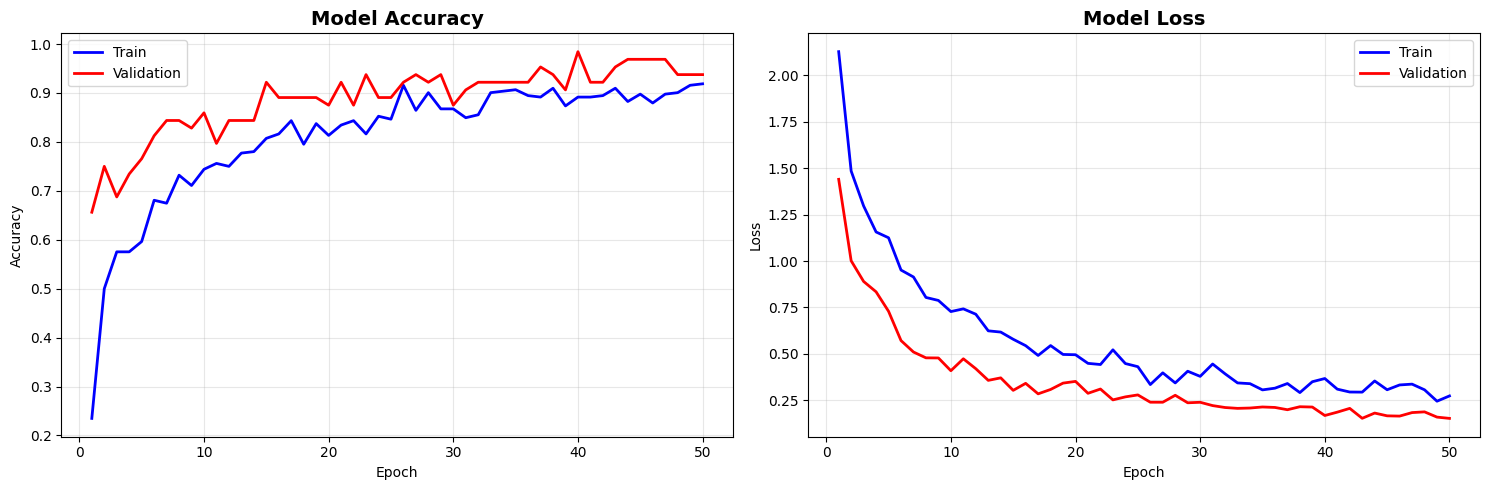


Final Training Accuracy:   91.87%
Final Validation Accuracy: 93.75%
Final Training Loss:       0.2737
Final Validation Loss:     0.1528


In [ ]:
# 1. Extract metrics directly from history
h = history.history
epochs = range(1, len(h['accuracy']) + 1)

# 2. Set up side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
ax1.plot(epochs, h['accuracy'], 'b-', label='Train', linewidth=2)
ax1.plot(epochs, h['val_accuracy'], 'r-', label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set(xlabel='Epoch', ylabel='Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss Plot
ax2.plot(epochs, h['loss'], 'b-', label='Train', linewidth=2)
ax2.plot(epochs, h['val_loss'], 'r-', label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Print concise final results
print(f"\n{'='*40}")
print(f"Final Training Accuracy:   {h['accuracy'][-1]:.2%}")
print(f"Final Validation Accuracy: {h['val_accuracy'][-1]:.2%}")
print(f"Final Training Loss:       {h['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {h['val_loss'][-1]:.4f}")
print(f"{'='*40}")

### **Make Predictions on Validation Images**

Correct predictions: 60/64 (93.75%)



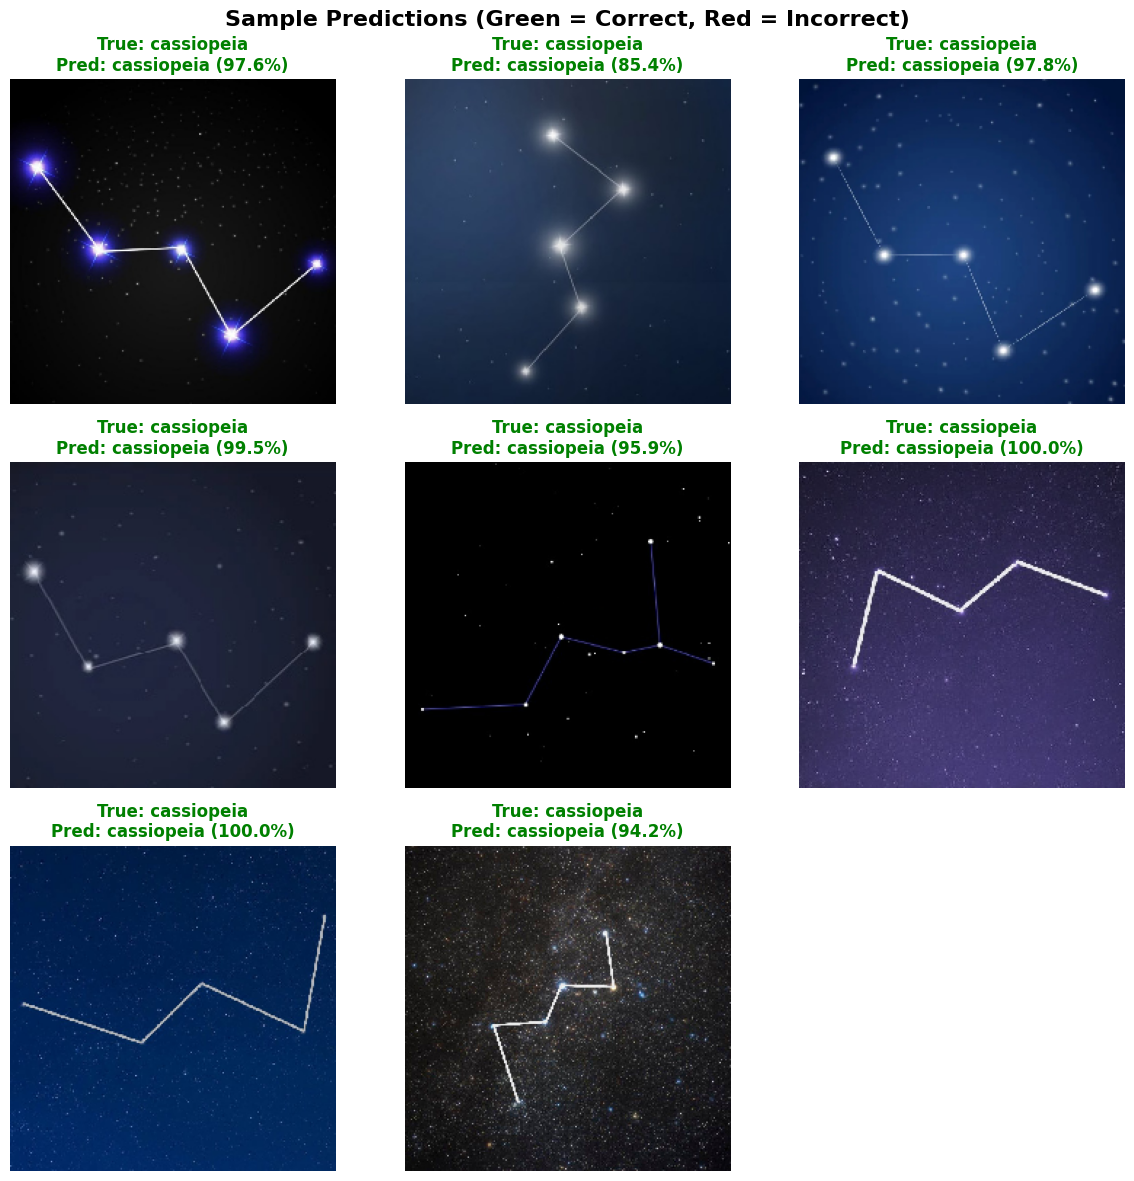

In [ ]:
# 1. Get overall predictions
validation_generator.reset()
predictions = model.predict(validation_generator, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

# Calculate and print accuracy fraction
correct = np.sum(predicted_classes == true_classes)
total = len(true_classes)
print(f"Correct predictions: {correct}/{total} ({correct/total:.2%})\n")

# 2. Grab a single batch for visual sampling
validation_generator.reset()
images, labels = next(validation_generator)
sample_preds = model.predict(images, verbose=0)

# 3. Plot 9 sample images
plt.figure(figsize=(12, 12))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    true_idx = np.argmax(labels[i])
    pred_idx = np.argmax(sample_preds[i])
    confidence = sample_preds[i][pred_idx] * 100

    color = 'green' if true_idx == pred_idx else 'red'

    plt.title(f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]} ({confidence:.1f}%)",
              color=color, fontweight='bold', fontsize=12)
    plt.axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Incorrect)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Confusion Matrix**

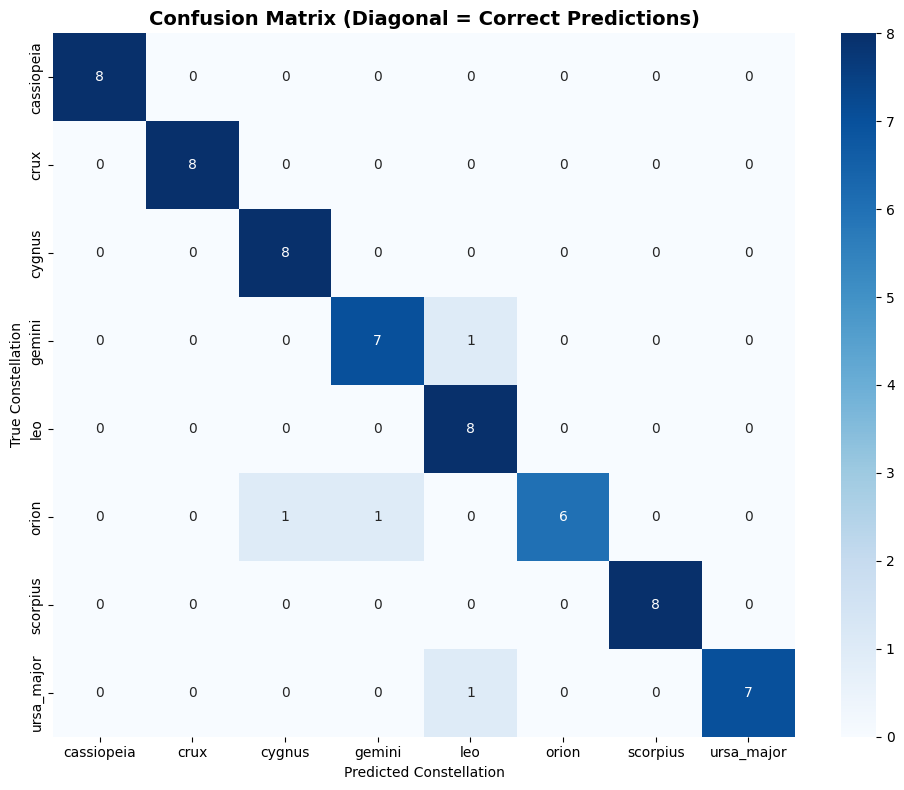


Detailed Performance per Constellation:
              precision    recall  f1-score   support

  cassiopeia       1.00      1.00      1.00         8
        crux       1.00      1.00      1.00         8
      cygnus       0.89      1.00      0.94         8
      gemini       0.88      0.88      0.88         8
         leo       0.80      1.00      0.89         8
       orion       1.00      0.75      0.86         8
    scorpius       1.00      1.00      1.00         8
  ursa_major       1.00      0.88      0.93         8

    accuracy                           0.94        64
   macro avg       0.95      0.94      0.94        64
weighted avg       0.95      0.94      0.94        64



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Get predictions (Note: You can skip this if you saved them from the last block)
validation_generator.reset()
predicted_classes = np.argmax(model.predict(validation_generator, verbose=0), axis=1)
true_classes = validation_generator.classes

# 2. Generate Confusion Matrix Plot
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(true_classes, predicted_classes),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix (Diagonal = Correct Predictions)', fontsize=14, fontweight='bold')
plt.ylabel('True Constellation')
plt.xlabel('Predicted Constellation')

plt.tight_layout()
plt.show()

# 3. Print the Detailed Classification Report
print(f"\n{'='*60}")
print("Detailed Performance per Constellation:")
print(f"{'='*60}")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

### **Save the Model**

In [ ]:
import os
import json
from tensorflow import keras

MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "constellation_classifier.keras")
classes_path = os.path.join(MODEL_DIR, "classes.json")

# Save model and class names
model.save(model_path)

with open(classes_path, "w") as f:
    json.dump(class_names, f)

print(f"✓ Model saved to: {model_path}")
print(f"✓ Classes saved to: {classes_path}")

# Quick reference for loading later:
# loaded_model = keras.models.load_model(model_path)
# with open(classes_path, 'r') as f: loaded_classes = json.load(f)

✓ Model saved to: /content/drive/MyDrive/models/constellation_classifier.keras
✓ Classes saved to: /content/drive/MyDrive/models/classes.json


### **Test on New Images**

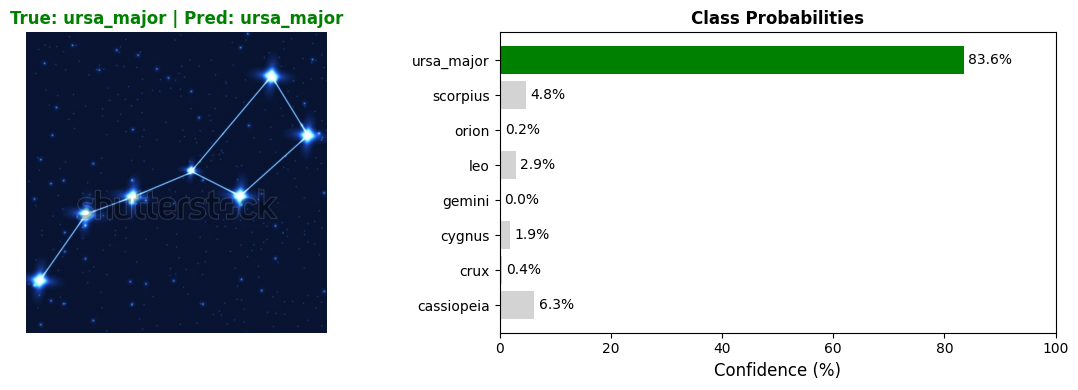


Result: ✅ Correct
Confidence: 83.57%


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_constellation(img_path, model, class_names):
    """Loads an image, pre-processes it, and returns the prediction."""
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = np.expand_dims(image.img_to_array(img) / 255.0, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(probs)

    return class_names[pred_idx], probs[pred_idx] * 100, probs

# 1. Grab a random test image
true_class = np.random.choice(class_names)
class_dir = os.path.join(VAL_DIR, true_class)
img_name = np.random.choice([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png'))])
test_img_path = os.path.join(class_dir, img_name)

# 2. Make the prediction
pred_class, conf, probs = predict_constellation(test_img_path, model, class_names)

# 3. Visualize the result
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Image Plot
title_color = 'green' if true_class == pred_class else 'red'
ax1.imshow(plt.imread(test_img_path))
ax1.set_title(f"True: {true_class} | Pred: {pred_class}", fontweight='bold', color=title_color)
ax1.axis('off')

# Probability Bar Chart
colors = ['green' if name == pred_class else 'lightgray' for name in class_names]
bars = ax2.barh(class_names, probs * 100, color=colors)
ax2.set_xlabel('Confidence (%)', fontsize=12)
ax2.set_title('Class Probabilities', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

# 4. Quick terminal summary
print(f"\nResult: {'✅ Correct' if pred_class == true_class else '❌ Incorrect'}")
print(f"Confidence: {conf:.2f}%")

### **Interface**

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nest_asyncio
from google.colab import drive

# --- 1. SETUP & CONFIG ---
nest_asyncio.apply()
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/models/cnn_model.keras"

CONSTELLATION_DATA = {
    "cassiopeia": {"Name": "Cassiopeia", "Abbr": "Cas", "Meaning": "The Queen", "Brightest Star": "Schedar", "Hemisphere": "Northern", "Best Viewing": "November", "Description": "Recognizable by its distinct 'W' or 'M' shape formed by five bright stars, representing a vain queen from Greek mythology."},
    "crux": {"Name": "Crux", "Abbr": "Cru", "Meaning": "The Southern Cross", "Brightest Star": "Acrux", "Hemisphere": "Southern", "Best Viewing": "May", "Description": "The smallest but one of the most famous constellations, featuring a distinct cross shape that guided navigators for centuries."},
    "cygnus": {"Name": "Cygnus", "Abbr": "Cyg", "Meaning": "The Swan", "Brightest Star": "Deneb", "Hemisphere": "Northern", "Best Viewing": "September", "Description": "Often called the Northern Cross, this large constellation appears to be flying down the Milky Way and contains the Cygnus X-1 black hole."},
    "gemini": {"Name": "Gemini", "Abbr": "Gem", "Meaning": "The Twins", "Brightest Star": "Pollux", "Hemisphere": "Northern", "Best Viewing": "February", "Description": "A prominent zodiac constellation dominated by the bright 'twin' stars Castor and Pollux."},
    "leo": {"Name": "Leo", "Abbr": "Leo", "Meaning": "The Lion", "Brightest Star": "Regulus", "Hemisphere": "Northern", "Best Viewing": "April", "Description": "Easily identified by a 'sickle' or backwards question mark asterism that forms the lion's head and mane."},
    "orion": {"Name": "Orion", "Abbr": "Ori", "Meaning": "The Hunter", "Brightest Star": "Rigel", "Hemisphere": "Equatorial", "Best Viewing": "January", "Description": "Characterized by Orion's Belt (three stars in a row) and the bright stars Rigel and Betelgeuse. His 'sword' contains a massive star nursery."},
    "scorpius": {"Name": "Scorpius", "Abbr": "Sco", "Meaning": "The Scorpion", "Brightest Star": "Antares", "Hemisphere": "Southern", "Best Viewing": "July", "Description": "A winding zodiac constellation that genuinely resembles a scorpion, anchored by the reddish supergiant star Antares ('Rival of Mars')."},
    "ursa_major": {"Name": "Ursa Major", "Abbr": "UMa", "Meaning": "The Great Bear", "Brightest Star": "Alioth", "Hemisphere": "Northern", "Best Viewing": "April", "Description": "Famous for containing the Big Dipper asterism, this massive constellation points the way to the North Star."}
}

# Automatically generate class names to ensure they perfectly match the dictionary keys
CLASS_NAMES = list(CONSTELLATION_DATA.keys())

# --- 2. LOAD MODEL ---
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✓ Model loaded successfully!")

# --- 3. PREDICTION LOGIC ---
def predict(image):
    if image is None:
        return "No image uploaded", "", None

    # Preprocess
    image_resized = tf.image.resize(image, (224, 224))
    image_batch = np.expand_dims(image_resized / 255.0, axis=0)

    # Predict
    preds = model.predict(image_batch, verbose=0)[0]
    top_index = int(np.argmax(preds))
    top_label = CLASS_NAMES[top_index]
    confidence = float(preds[top_index]) * 100

    # Generate Markdown Table
    info = CONSTELLATION_DATA.get(top_label)
    if info:
        description_md = f"### About {info['Name']}\n\n| Feature | Details |\n| :--- | :--- |\n"
        for key, value in info.items():
            if key != "Name":
                description_md += f"| **{key}** | {value} |\n"
    else:
        description_md = "*No additional information available for this constellation.*"

    # Generate Confidence Chart
    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    colors = ['#6a85ff' if i != top_index else '#b86bff' for i in range(len(CLASS_NAMES))]
    ax.bar(CLASS_NAMES, preds * 100, color=colors)

    ax.set_ylabel("Confidence (%)", color="white")
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', colors='white', rotation=45)
    ax.tick_params(axis='y', colors='white')

    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']: ax.spines[spine].set_color('white')

    plt.tight_layout()
    display_name = info['Name'] if info else top_label.upper()

    return f"🌟 **{display_name.upper()}** ({confidence:.2f}%)", description_md, fig

# --- 4. CSS STYLING ---
css = """
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600&display=swap');
.gradio-container { background: linear-gradient(135deg, #0f172a, #1e293b); font-family: 'Poppins', sans-serif; }
.glass { background: rgba(255, 255, 255, 0.08); backdrop-filter: blur(18px); -webkit-backdrop-filter: blur(18px); border-radius: 20px; border: 1px solid rgba(255, 255, 255, 0.15); padding: 30px; color: white; box-shadow: 0 8px 32px 0 rgba(0, 0, 0, 0.4); }
.glass table { width: 100%; border-collapse: collapse; margin-top: 15px; background: rgba(0, 0, 0, 0.15); border-radius: 8px; overflow: hidden; }
.glass th, .glass td { padding: 12px 16px; text-align: left; border-bottom: 1px solid rgba(255, 255, 255, 0.1); }
.glass th { background: rgba(106, 133, 255, 0.15); color: #b86bff; font-weight: 600; letter-spacing: 0.5px; }
.glass tr:last-child td { border-bottom: none; }
.glass tr:hover { background: rgba(255, 255, 255, 0.05); }
.tab-nav button { background: rgba(255, 255, 255, 0.1) !important; color: white !important; border-radius: 12px !important; padding: 8px 18px !important; }
.tab-nav button.selected { background: linear-gradient(135deg, #6a85ff, #b86bff) !important; font-weight: bold; box-shadow: 0 0 12px rgba(106, 133, 255, 0.6); }
button { font-weight: 600 !important; border-radius: 12px !important; letter-spacing: 1px; }
button.primary { background: linear-gradient(135deg, #6a85ff, #b86bff) !important; border: none !important; color: white !important; box-shadow: 0 4px 15px rgba(106, 133, 255, 0.5); }
button:not(.primary) { background: rgba(255,255,255,0.15) !important; color: white !important; border: 1px solid rgba(255,255,255,0.2) !important; }
button:hover { transform: translateY(-2px); transition: 0.2s ease; }
"""

# --- 5. UI BUILD ---
with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo:
    with gr.Tabs() as main_tabs:

        # HOME TAB
        with gr.Tab(" HOME ", id=0):
            with gr.Column(elem_classes="glass"):
                gr.Markdown("# Constellation Identification\n### Welcome to your personal star guide.\nUpload an image of the night sky and let Kiki and Jiji identify the stars for you.")
                gr.Image('/content/drive/MyDrive/UI Images/Background.png', show_label=False, interactive=False)
                with gr.Row():
                    btn_goto_identify = gr.Button("IDENTIFY ", variant="primary")
                    btn_goto_guide = gr.Button("USER  GUIDE")
                    btn_goto_config = gr.Button("CONFIG")

        # GUIDE TAB
        with gr.Tab(" GUIDE ", id=1):
            with gr.Column(elem_classes="glass"):
                gr.Image('/content/drive/MyDrive/UI Images/Guser Guide.png', show_label=False, interactive=False)

        # IDENTIFY TAB
        with gr.Tab(" IDENTIFY ", id=2):
            with gr.Column(elem_classes="glass"):
                gr.Markdown("# 🔭 Upload & Analyze")
                with gr.Row():
                    with gr.Column():
                        img_input = gr.Image(label="Upload Sky Image", type="numpy")
                        analyze_btn = gr.Button("✨ Identify Constellation", variant="primary")
                    with gr.Column():
                        res_text = gr.Markdown()
                        res_desc = gr.Markdown()
                        res_plot = gr.Plot(label="Confidence")

                analyze_btn.click(fn=predict, inputs=img_input, outputs=[res_text, res_desc, res_plot])

        # CONFIG TAB
        with gr.Tab(" CONFIG ", id=3):
            with gr.Column(elem_classes="glass"):
                gr.Image('/content/drive/MyDrive/UI Images/Model Configuration.png', show_label=False, interactive=False)

    # Navigation Routing
    btn_goto_identify.click(lambda: gr.Tabs(selected=2), outputs=main_tabs)
    btn_goto_guide.click(lambda: gr.Tabs(selected=1), outputs=main_tabs)
    btn_goto_config.click(lambda: gr.Tabs(selected=3), outputs=main_tabs)

# --- 6. LAUNCH ---
demo.launch(debug=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model...
✓ Model loaded successfully!


/tmp/ipykernel_201/4265150349.py:98: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_201/4265150349.py:98: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://66697bff84bbd98f5c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://66697bff84bbd98f5c.gradio.live
